In [11]:
!pip install torchmetrics
!pip install -q torchmetrics pycocotools
import pandas as pd
import os
from PIL import Image, ImageDraw
from pathlib import Path
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torchvision
from torchvision.transforms import v2
from torchvision import tv_tensors
from torchmetrics.detection.mean_ap import MeanAveragePrecision

#to follow progres during training (train time)
from tqdm import tqdm

#for fast predictor (predict objects)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

#for mask R CNN model (predicts mask)
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.ops import box_iou # Corrected import for box_iou
from torch.utils.data import DataLoader, Subset #for sample table
import cv2
from torchvision.models.detection import (
    maskrcnn_resnet50_fpn_v2,
    MaskRCNN_ResNet50_FPN_V2_Weights
)
# and for iou
from collections import namedtuple
import numpy as np

#for maP_mask

from torchmetrics.detection.mean_ap import MeanAveragePrecision

#for randomness
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#pathway to drive file
from google.colab import drive
drive.mount('/content/drive')

#copy all to content, to avoid long loading time with drive mounting (once)
import shutil
from pathlib import Path # Ensure Path is imported here
import os

if not os.path.exists('/content/Clouds-1000'):
    shutil.copytree('/content/drive/MyDrive/Clouds-1000', '/content/Clouds-1000')
else:
    #check for subfiles
    masks_ok = len(list(Path('/content/Clouds-1000/all_images_and_labels/masks').glob('*.json'))) > 100
    small_images_content_path = Path('/content/Clouds-1000/all_images_and_labels/images_small')
    small_ok  = len(list(small_images_content_path.glob('*.jpg'))) > 100

    if not masks_ok:
        shutil.copytree('/content/drive/MyDrive/Clouds-1000/all_images_and_labels/masks',
                        '/content/Clouds-1000/all_images_and_labels/masks', dirs_exist_ok=True)
    if not small_ok:
        # Corrected: Copy from 'images' in Drive to 'images_small' in /content
        # Ensure the destination directory exists if copying only files
        if not small_images_content_path.exists():
            small_images_content_path.mkdir(parents=True, exist_ok=True)
        # Copy contents from images in Drive to images_small in content
        source_images_drive_path = Path('/content/drive/MyDrive/Clouds-1000/all_images_and_labels/images')
        if source_images_drive_path.exists():
            # Copy files individually to handle cases where shutil.copytree might behave unexpectedly with dirs_exist_ok=True and existing non-empty dest
            for img_file in source_images_drive_path.glob('*.jpg'):
                shutil.copy(img_file, small_images_content_path / img_file.name)
        else:
            print(f"Warning: Source image directory not found: {source_images_drive_path}")

# Recalculate image and mask counts after potential copy operations
print(f"Images: {len(list(Path('/content/Clouds-1000/all_images_and_labels/images_small').glob('*.jpg')))}")
print(f"Masks:  {len(list(Path('/content/Clouds-1000/all_images_and_labels/masks').glob('*.json')))}")

dir_all = Path('/content/Clouds-1000/all_images_and_labels')

image_path=dir_all/'images'
mask_path=dir_all/'masks'
small_path = dir_all/'images_small'

# Try to get image_files from small_path first
image_files=list(sorted(small_path.glob('*.jpg')))

# If small_path is empty, try the original image_path as a fallback
if not image_files:
    print("Warning: No images found in 'images_small'. Attempting to load from 'images' directory as fallback.")
    image_files = list(sorted(image_path.glob('*.jpg')))
    if not image_files:
        print("Error: No images found in 'images' directory either. Please ensure your Google Drive 'images' folder contains .jpg files.")

mask_files=list(sorted(mask_path.glob('*.json')))

print(f"Final Image Files Count: {len(image_files)}")
print(f"Final Mask Files Count: {len(mask_files)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Images: 996
Masks:  996
Final Image Files Count: 996
Final Mask Files Count: 996


In [13]:
# List contents of the 'Clouds-1000' directory in Google Drive
drive_path = '/content/drive/MyDrive/Clouds-1000'

if os.path.exists(drive_path):
    print(f"Contents of {drive_path}:")
    for item in os.listdir(drive_path):
        print(f"- {item}")

    # Optionally, check inside all_images_and_labels if it exists
    all_images_path = os.path.join(drive_path, 'all_images_and_labels')
    if os.path.exists(all_images_path):
        print(f"\nContents of {all_images_path}:")
        for item in os.listdir(all_images_path):
            print(f"- {item}")
    else:
        print(f"\n{all_images_path} does not exist.")

else:
    print(f"The directory {drive_path} does not exist in your Google Drive. Please verify the path.")

Contents of /content/drive/MyDrive/Clouds-1000:
- obj_class_to_machine_color.json
- meta.json
- all_images_and_labels
- Performance_SampleSize_final.jpeg

Contents of /content/drive/MyDrive/Clouds-1000/all_images_and_labels:
- images
- masks


Selected image: 2021-04-09-07-28.jpg


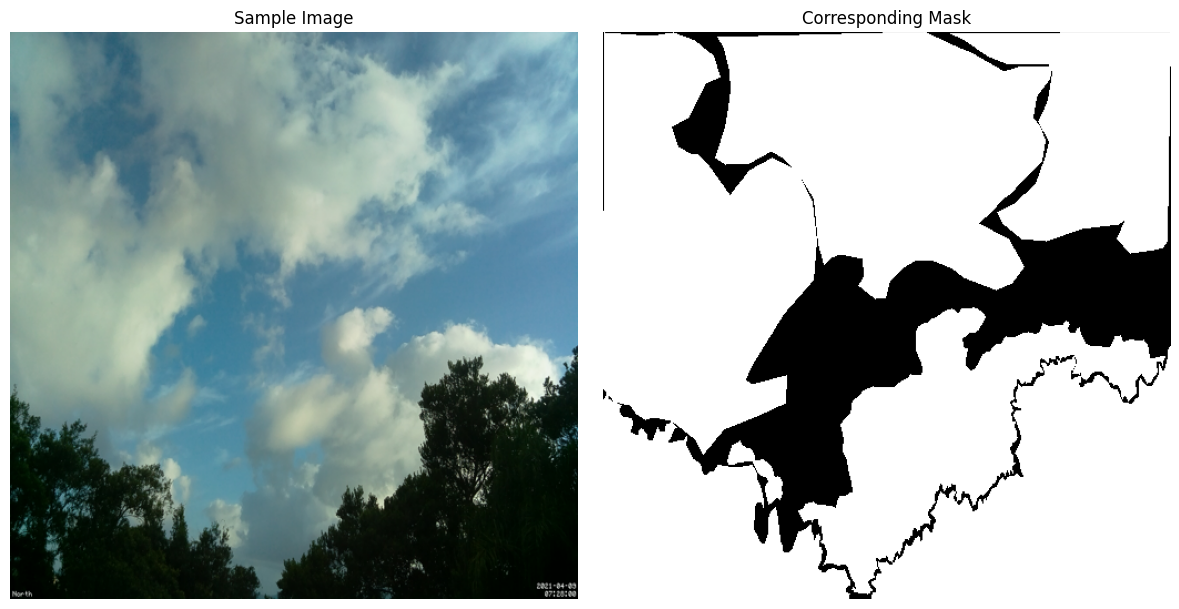

In [14]:
# Check if image_files is empty before proceeding
if not image_files:
    print("Error: The 'image_files' list is empty. Please ensure image files are correctly loaded and available in the specified path.")
else:
    # Select a random image file
    random_image_file = random.choice(image_files)
    print(f"Selected image: {random_image_file.name}")

    # Construct the corresponding mask file path
    # The mask files are in mask_path, named like 'image_name.jpg.json'
    mask_filename = random_image_file.name + '.json'
    random_mask_file = mask_path / mask_filename

    if not random_mask_file.exists():
        print(f"Error: Mask file not found at {random_mask_file}")
    else:
        # Load the image
        img = Image.open(random_image_file).convert('RGB')

        # Load the mask data from JSON
        with open(random_mask_file, 'r') as f:
            mask_data = json.load(f)

        # Assuming the images were resized to 512x512 for training/display
        # The CustomDataset class uses 512x512, so let's stick to that for display
        display_width, display_height = 512, 512

        # Create a blank mask image for visualization
        # Initialize with zeros to represent background
        visual_mask = Image.new('L', (display_width, display_height), 0)
        draw = ImageDraw.Draw(visual_mask)

        # Original image dimensions (as used in CustomDataset for scaling)
        orig_w, orig_h = img.size
        scale_x = display_width / orig_w
        scale_y = display_height / orig_h

        for obj in mask_data['objects']:
            polygon = obj['points']['exterior']
            # Scale polygons to the display dimensions
            scaled_polygon = [(p[0] * scale_x, p[1] * scale_y) for p in polygon]
            draw.polygon(scaled_polygon, fill=255) # Draw in white (255) for object

        # Display the original image and the mask
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        axes[0].imshow(img.resize((display_width, display_height))) # Resize image for display consistency
        axes[0].set_title('Sample Image')
        axes[0].axis('off')

        axes[1].imshow(visual_mask, cmap='gray')
        axes[1].set_title('Corresponding Mask')
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

In [15]:
#training model: Mask R-CNN ResNet-50 FPN
model=torchvision.models.detection.maskrcnn_resnet50_fpn_v2(weights=MaskRCNN_ResNet50_FPN_V2_Weights.DEFAULT,
                                                            trainable_backbone_layers=5,min_size=512,max_size=768)
num_classes = 6  #number of classes, including background for training
in_features_box = model.roi_heads.box_predictor.cls_score.in_features #get number of input features for classifier
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
#change only last layer
model.roi_heads.box_predictor =FastRCNNPredictor(in_features_box, num_classes)#replace model's head with new one (for number of classes in dataset)
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes) #add hidden layer as argument for maskRCNN

#prepare data for R CNN
# Define transformations (equal to ResNet18 baseline) & resize images for smaller data
#transform = T.Compose([
    #T.Resize((224, 224)), # Explicitly resize images to 224x224 to match target scaling
    #T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2), #for DataAugmentation
    #T.ToTensor(),
    #T.Normalize([0.485, 0.456, 0.406],
                         #[0.229, 0.224, 0.225])
#]) #mean and std for generalized ImageNet dataset for RGB values

train_transform = v2.Compose([
    v2.ToImage(),
    # Safe augmentation: changes image colors only
    v2.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2
    ),
    # Safe geometric augmentation:
    # image, boxes, and masks are flipped together
    v2.RandomHorizontalFlip(p=0.5),
    # Resize image, masks, and boxes together
    v2.Resize(size=512, max_size=768),
    # Removes invalid boxes after geometric transforms
    v2.SanitizeBoundingBoxes(),
    # Convert image to float [0, 1]
    v2.ToDtype(torch.float32, scale=True),
    # Convert tv_tensors back to normal tensors
    v2.ToPureTensor(),
])

eval_transform = v2.Compose([
    v2.ToImage(),
    v2.Resize(size=512, max_size=768),
    v2.SanitizeBoundingBoxes(),
    v2.ToDtype(torch.float32, scale=True),
    v2.ToPureTensor(),
])

#create Custom Dataset to organise data in boxes/polygons and labels/classes
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, df, transforms=None):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms

        self.classes = [
            'Arvore',
            'Estratocumuliformes',
            'Cirriformes',
            'Estratiformes',
            'Cumuliformes'
        ]

        # class index starts at 1 because 0 is background
        self.class_to_idx = {c: i + 1 for i, c in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['images']
        mask_path = self.df.iloc[idx]['masks']

        image = Image.open(img_path).convert("RGB")

        # Important: get real image size
        width, height = image.size

        with open(mask_path) as f:
            data = json.load(f)

        boxes = []
        labels = []
        masks = []

        for obj in data["objects"]:
            polygon = obj["points"]["exterior"]

            x_coords = [p[0] for p in polygon]
            y_coords = [p[1] for p in polygon]

            x1 = max(0, min(x_coords))
            y1 = max(0, min(y_coords))
            x2 = min(width, max(x_coords))
            y2 = min(height, max(y_coords))

            # skip invalid boxes
            if x2 <= x1 or y2 <= y1:
                continue

            class_name = obj["classTitle"]

            # skip unknown classes, just in case
            if class_name not in self.class_to_idx:
                continue

            label = self.class_to_idx[class_name]

            # Create mask at original image size
            mask_img = Image.new("L", (width, height), 0)
            ImageDraw.Draw(mask_img).polygon(
                [tuple(p) for p in polygon],
                fill=1
            )

            mask = torch.as_tensor(np.array(mask_img), dtype=torch.uint8)

            boxes.append([x1, y1, x2, y2])
            labels.append(label)
            masks.append(mask)

        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            masks = torch.stack(masks)
        else:
            # Correct empty target format for detection models
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            masks = torch.zeros((0, height, width), dtype=torch.uint8)

        # Wrap boxes and masks so transforms.v2 knows how to transform them
        boxes = tv_tensors.BoundingBoxes(
            boxes,
            format="XYXY",
            canvas_size=(height, width)
        )

        masks = tv_tensors.Mask(masks)

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": torch.tensor([idx])
        }

        if self.transforms is not None:
            image, target = self.transforms(image, target)

        # Ensure correct dtypes after transforms
        target["boxes"] = target["boxes"].to(torch.float32)
        target["labels"] = target["labels"].to(torch.int64)
        target["masks"] = target["masks"].to(torch.uint8)

        return image, target

In [16]:
print(model)#.roi_heads.mask_predictor) #get number of hidden layers

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(512,), max_size=768, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          

In [17]:
rows = []

for img_path in sorted(image_files):
    json_path = mask_path / f"{img_path.name}.json"

    if json_path.exists():
        rows.append({
            "images": img_path,
            "masks": json_path
        })
    else:
        print(f"Missing mask for: {img_path.name}")

df = pd.DataFrame(rows)

print(f"Matched image/mask pairs: {len(df)}")
# split into train, val, test sets: train_size=0.7, test_size=0.15 * 2
train_df, rest_df=train_test_split(df, test_size=0.25, random_state=42) #70% train
val_df, test_df=train_test_split(rest_df, test_size=0.5, random_state=42) #je 20%

#check size
print(f"Set sizes:\nTrain:\t{len(train_df)}")
print(f"Val:\t{len(val_df)}")
print(f"Test:\t{len(test_df)}")

#load datasets
train_ds = CustomDataset(train_df, transforms=train_transform)
val_ds   = CustomDataset(val_df,   transforms=eval_transform)
test_ds  = CustomDataset(test_df,  transforms=eval_transform)
train_loader = DataLoader(
    train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=lambda x: tuple(zip(*x))
)

valid_loader = DataLoader(
    val_ds,
    batch_size=2,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=lambda x: tuple(zip(*x))
)

test_loader = DataLoader(
    test_ds,
    batch_size=2,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=lambda x: tuple(zip(*x))
)

Matched image/mask pairs: 996
Set sizes:
Train:	747
Val:	124
Test:	125


In [18]:
##implement early stopping
class EarlyStopping:
  def __init__ (self, patience=5, min_delta=0.01):
    self.patience=patience #wait on how many epochs
    self.min_delta=min_delta #smallest amount of improvement
    self.counter=0
    self.best_map=-float("inf")

  def check(self, current_map, model, save_path):
    if current_map > self.best_map + self.min_delta:
      self.best_map=current_map
      self.counter=0
      torch.save(model.state_dict(), save_path)
      print(f'Improvement - maP: {current_map:.4f}')
      return False #continue
    else:
      self.counter+=1
      print(f'no further improvement ({self.counter}/{self.patience})')
      if self.counter >= self.patience:
        print('Early Stopping')
        return True # stop
      return False

In [10]:
####ONLY when new training needed:
early_stopping=EarlyStopping(patience=5, min_delta=0.001)

model.to(device)
#hidden layer einfrieren: backbone layer 1 & 2
for name, param in model.backbone.body.named_parameters():
  if 'layer1' in name or 'layer2' in name:
    param.requires_grad=False

# Set up the optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.0025, momentum=0.9, weight_decay=0.0005) # Further adjusted lr to 0.00001
num_epochs = 20
#lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5) #gamma 0.1 very aggressive-> to 0.5
#2nd lr scheduler variation (smoother decay):
lr_scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs,eta_min=1e-6 )
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    # Training loop
    #with loading bar
    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        optimizer.zero_grad()
        # Forward pass
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        # Backward pass
        losses.backward()
        optimizer.step()
        train_loss += losses.item()
    # Update learning rate
    lr_scheduler.step()

    #evaluate training (without gradient calculation, only prediction: no_grad)
    model.eval()
    ious=[]
    map_mask=MeanAveragePrecision(iou_type='segm') #use mask in iou and maP evaluation
    with torch.no_grad():
      for images, targets in valid_loader: #targets optional as _, as it is not used here, only appearing in tupel (getitem)
        images=list(img.to(device) for img in images)
        prediction=model(images) #forward calculation through call

        for pred, target in zip(prediction, targets):
          preds_boxes=pred['boxes'].cpu()
          true_boxes=target['boxes'].cpu()

          if len(preds_boxes)==0 or len(true_boxes)==0: #jump over empty boxes
            continue
          iou_matrix=box_iou(preds_boxes, true_boxes)
          best_iou=iou_matrix.max(dim=1).values #choose best predicition for every original (ground truth) box
          ious.extend(best_iou.tolist())

        # Handle case where no valid IoU scores are calculated
        if len(ious) > 0:
            mean_iou=sum(ious)/len(ious)
        else:
            mean_iou = 0.0 # Assign a default value if no IoU scores are available
            print("Warning: No valid IoU scores were calculated for this epoch. Setting mean_iou to 0.0.")

        #for maP_mask change to cpu (not gpu compatible)
        true_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets]
        preds_cpu = [{'boxes': p['boxes'].cpu(),'scores': p['scores'].cpu(),
                      'labels': p['labels'].cpu(),
                      'masks': (p['masks'].cpu() > 0.5).squeeze(1)}  #change from floatto binary
                      for p in prediction]
        map_mask.update(preds_cpu, true_cpu)

    result=map_mask.compute()
    val_map=result['map'].item()

    print(f'Epoch: {epoch + 1}, Loss: {train_loss / len(train_loader)}')

    #early stopping
    if early_stopping.check(val_map, model, '/content/drive/MyDrive/best_model.pth'):
      break

print("Training complete!")
#load best model
model.load_state_dict(torch.load('/content/drive/MyDrive/best_model.pth', map_location=device)) # Corrected to load_state_dict
print(f"Finished with best model: mAP={early_stopping.best_map:.4f}")

Epoch 1/20: 100%|██████████| 374/374 [05:33<00:00,  1.12it/s]


Epoch: 1, Loss: 1.04945592064271
Improvement - maP: 0.2338


Epoch 2/20: 100%|██████████| 374/374 [05:25<00:00,  1.15it/s]


Epoch: 2, Loss: 0.8408559025688604
Improvement - maP: 0.2677


Epoch 3/20: 100%|██████████| 374/374 [05:18<00:00,  1.17it/s]


...

Epoch: 18, Loss: 0.3457024695281995
no further improvement (1/5)


Epoch 19/20: 100%|██████████| 374/374 [05:51<00:00,  1.07it/s]


Epoch: 19, Loss: 0.3490912722632847
no further improvement (2/5)


Epoch 20/20: 100%|██████████| 374/374 [05:52<00:00,  1.06it/s]


Epoch: 20, Loss: 0.3454338456279932
no further improvement (3/5)
Training complete!
Finished with best model: mAP=0.3582


In [19]:
#####IF already trained and model saved:
model.to(device)
model.load_state_dict(torch.load('/content/drive/MyDrive/best_model.pth', map_location=device))
model.eval()

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(512,), max_size=768, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          

In [20]:
def compute_mean_iou(preds, targets, score_threshold=0.5):
    ious = []

    for pred, target in zip(preds, targets):
        pred_masks = pred["masks"].cpu().bool()
        pred_labels = pred["labels"].cpu()
        pred_scores = pred["scores"].cpu()

        target_masks = target["masks"].cpu().bool()
        target_labels = target["labels"].cpu()

        # Keep only confident predictions
        keep = pred_scores >= score_threshold
        pred_masks = pred_masks[keep]
        pred_labels = pred_labels[keep]

        # For each ground-truth mask, find best matching predicted mask
        for gt_mask, gt_label in zip(target_masks, target_labels):
            same_class = pred_labels == gt_label

            if same_class.sum() == 0:
                ious.append(0.0)
                continue

            candidate_masks = pred_masks[same_class]

            best_iou = 0.0

            for pred_mask in candidate_masks:
                intersection = torch.logical_and(pred_mask, gt_mask).sum().item()
                union = torch.logical_or(pred_mask, gt_mask).sum().item()

                if union > 0:
                    iou = intersection / union
                    best_iou = max(best_iou, iou)

            ious.append(best_iou)

    if len(ious) == 0:
        return 0.0

    return sum(ious) / len(ious)


# Evaluate loaded model
map_metric = MeanAveragePrecision(iou_type="segm")

all_preds = []
all_targets = []

model.eval()

with torch.no_grad():
    for images, targets in test_loader:   # or valid_loader if you want validation results
        images = [img.to(device) for img in images]

        preds = model(images)

        preds_for_map = []
        targets_for_map = []

        for p in preds:
            preds_for_map.append({
                "boxes": p["boxes"].cpu(),
                "scores": p["scores"].cpu(),
                "labels": p["labels"].cpu(),
                "masks": (p["masks"].cpu() > 0.5).squeeze(1)
            })

        for t in targets:
            targets_for_map.append({
                "boxes": t["boxes"].cpu(),
                "labels": t["labels"].cpu(),
                "masks": t["masks"].cpu().bool()
            })

        map_metric.update(preds_for_map, targets_for_map)

        all_preds.extend(preds_for_map)
        all_targets.extend(targets_for_map)

result = map_metric.compute()
mean_iou = compute_mean_iou(all_preds, all_targets, score_threshold=0.5)

print(f"Mean Average Precision mAP: {result['map']:.4f}")
print(f"mAP@50: {result['map_50']:.4f}")
print(f"mAP@75: {result['map_75']:.4f}")
print(f"Mean IoU: {mean_iou:.4f}")

Mean Average Precision mAP: 0.3609
mAP@50: 0.5497
mAP@75: 0.3730
Mean IoU: 0.5291


In [28]:

#train:80
train_df, rest_df=train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df=train_test_split(rest_df, test_size=0.5, random_state=42)
#load datasets
train_ds = CustomDataset(train_df, transforms=train_transform)
val_ds   = CustomDataset(val_df,   transforms=eval_transform)
test_ds  = CustomDataset(test_df,  transforms=eval_transform)
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=2, #load parallel
                          pin_memory=True, #faster gpu
                          collate_fn=lambda x: tuple(zip(*x)))
valid_loader = DataLoader(val_ds, batch_size=2, shuffle=False, num_workers=2, #load parallel
                          pin_memory=True, #faster gpu
                          collate_fn=lambda x: tuple(zip(*x)))
test_loader=DataLoader(test_ds, batch_size=2, shuffle=False, num_workers=2, #load parallel
                          pin_memory=True, #faster gpu
                          collate_fn=lambda x: tuple(zip(*x)))

#check how much training data is needed for success (with map)
sample_size = [50, 100, 300, 500, len(train_df)]
num_epochs = 5
map_results={}
for s in sample_size:
  s = min(s, len(train_ds))
  print(f'Amount of Training Data: {s}')
  set_seed(42)
  indices = torch.randperm(len(train_ds))[:s].tolist()
  sample_ds = Subset(train_ds, indices)
  sample_loader=DataLoader(sample_ds,batch_size=2, shuffle=True, num_workers=0,
        pin_memory=True, collate_fn=lambda x: tuple(zip(*x)))

  #training model: Mask R-CNN ResNet-50 FPN
  model_s=torchvision.models.detection.maskrcnn_resnet50_fpn_v2(weights=MaskRCNN_ResNet50_FPN_V2_Weights.DEFAULT,
                                                                    trainable_backbone_layers=5,min_size=512,max_size=768)
  num_classes = 6  #number of classes, including background for training
  in_features_box = model_s.roi_heads.box_predictor.cls_score.in_features #get number of input features for classifier
  in_features_mask = model_s.roi_heads.mask_predictor.conv5_mask.in_channels
  #change only last layer
  model_s.roi_heads.box_predictor =FastRCNNPredictor(in_features_box, num_classes)#replace model's head with new one (for number of classes in dataset)
  model_s.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes) #add hidden layer as argument for maskRCNN

  #hidden layer einfrieren: backbone layer 1 & 2
  for name, param in model_s.backbone.body.named_parameters():
    if 'layer1' in name or 'layer2' in name:
      param.requires_grad=False

  model_s.to(device)
  #num_epochs = 20
  params = [p for p in model_s.parameters() if p.requires_grad]
  optimizer = torch.optim.SGD(params, lr=0.0025, momentum=0.9, weight_decay=0.0005) #lr from 0.005 to 0.01
  lr_scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs,eta_min=1e-6 )
  for epoch in range(num_epochs):
      model_s.train() #no saving/later use of trainloss necessary
      running_loss = 0.0
      # Training loop
      for images, targets in tqdm(sample_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
          images = list(image.to(device) for image in images)
          targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
          optimizer.zero_grad()
          loss_dict = model_s(images, targets)
          losses = sum(loss_dict.values())
          losses.backward()
          optimizer.step()
          running_loss += losses.item()
      # Update learning rate (when num_epochs>10)
      lr_scheduler.step()

      avg_loss = running_loss / len(sample_loader)
      print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.4f}')
  print("Training complete!")
  #evaluate training (without gradient calculation, only prediction: no_grad)
  model_s.eval()
  map_metric=MeanAveragePrecision(iou_type='segm')
  with torch.no_grad():
    for images, targets in valid_loader: #targets optional as _, as it is not used here, only appearing in tupel (getitem)
        images=list(img.to(device) for img in images)
        preds  = model_s(images)
        preds_for_map = []
        targets_for_map = []
        for p in preds:
            preds_for_map.append({
                'boxes': p['boxes'].cpu(),
                'scores': p['scores'].cpu(),
                'labels': p['labels'].cpu(),
                'masks': (p['masks'].cpu() > 0.5).squeeze(1)
            })

        for t in targets:
            targets_for_map.append({
                'boxes': t['boxes'].cpu(),
                'labels': t['labels'].cpu(),
                'masks': t['masks'].cpu().bool()
            })

        map_metric.update(preds_for_map, targets_for_map)

  result=map_metric.compute()
  map_results[s] = result['map'].item()
  print(f'Amount={s}: maP = {map_results[s]:.4f}')
  del model_s
  del optimizer
  del lr_scheduler
  del loss_dict
  del losses
  torch.cuda.empty_cache()

Amount of Training Data: 50


Epoch 1/5: 100%|██████████| 25/25 [00:39<00:00,  1.59s/it]


Epoch 1/5, Loss: 2.1626


Epoch 2/5: 100%|██████████| 25/25 [00:39<00:00,  1.57s/it]


Epoch 2/5, Loss: 1.5419


...

Epoch 4/5: 100%|██████████| 398/398 [10:22<00:00,  1.56s/it]


Epoch 4/5, Loss: 0.7000


Epoch 5/5: 100%|██████████| 398/398 [10:22<00:00,  1.56s/it]

Epoch 5/5, Loss: 0.6610
Training complete!


Amount=796: maP = 0.3265


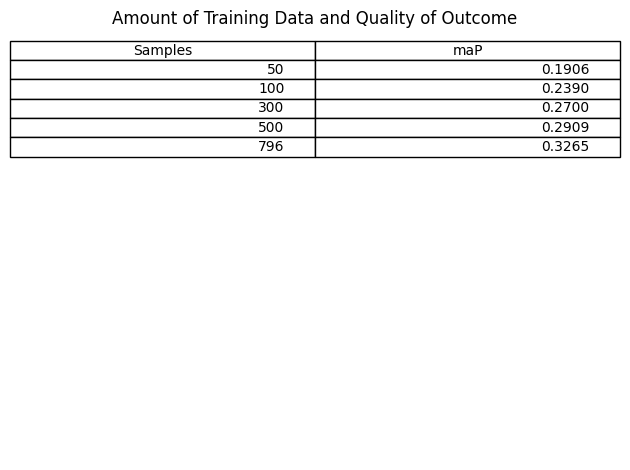

In [29]:
#print table
table_data=[]
for s,m in map_results.items():
  table_data.append([s, f'{m:.4f}'])

fig, ax = plt.subplots() #figsize=(10, 7)
ax.axis('off')
table = ax.table(cellText=table_data, colLabels=['Samples', 'maP'], loc='upper center')
ax.set_title('Amount of Training Data and Quality of Outcome') #fontsize=12, fontweight='bold'
plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/Clouds-1000/Performance_SampleSize_table_final.jpeg')
#plt.show()

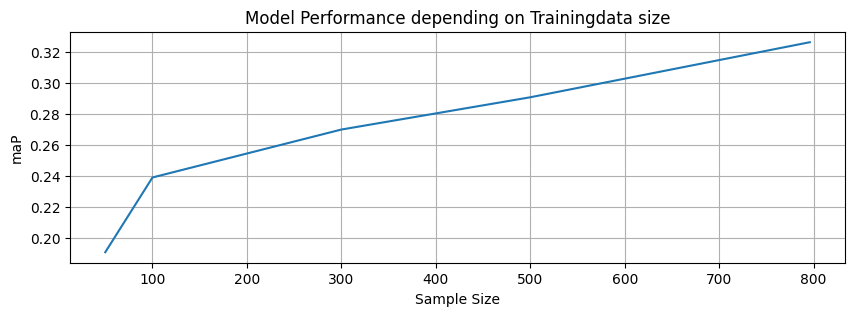

In [30]:
#visualitze table
plt.figure(figsize=(10,3))
plt.plot(list(map_results.keys()), list(map_results.values()))
plt.title('Model Performance depending on Trainingdata size')
plt.xlabel('Sample Size')
plt.ylabel('maP')
plt.grid(True)
plt.savefig('/content/drive/MyDrive/Clouds-1000/Performance_SampleSize_final.jpeg')
#plt.show()

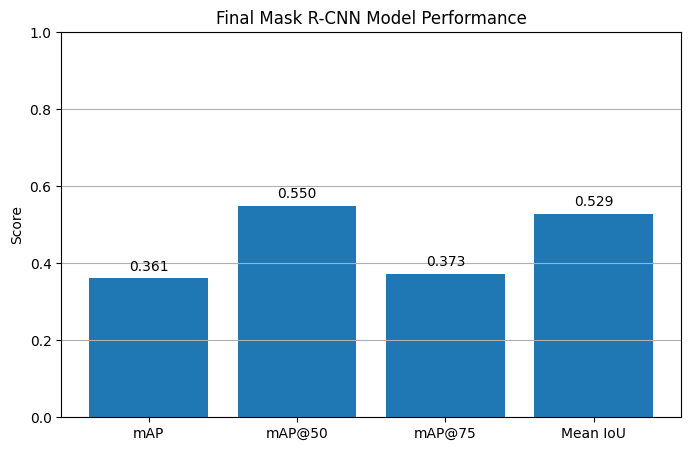

In [31]:
import matplotlib.pyplot as plt

metrics = {
    "mAP": 0.3609,
    "mAP@50": 0.5497,
    "mAP@75": 0.3730,
    "Mean IoU": 0.5291
}

plt.figure(figsize=(8, 5))
plt.bar(metrics.keys(), metrics.values())

for i, (name, value) in enumerate(metrics.items()):
    plt.text(i, value + 0.02, f"{value:.3f}", ha="center")

plt.title("Final Mask R-CNN Model Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

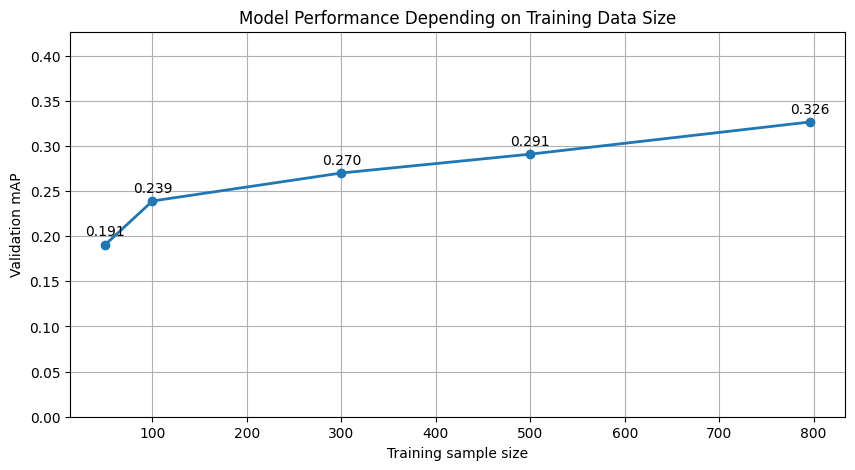

In [32]:
sizes = sorted(map_results.keys())
maps = [map_results[s] for s in sizes]

plt.figure(figsize=(10, 5))
plt.plot(sizes, maps, marker="o", linewidth=2)

for x, y in zip(sizes, maps):
    plt.text(x, y + 0.01, f"{y:.3f}", ha="center")

plt.title("Model Performance Depending on Training Data Size")
plt.xlabel("Training sample size")
plt.ylabel("Validation mAP")
plt.ylim(0, max(maps) + 0.1)
plt.grid(True)
plt.show()